# Karpathy GPT (Lean)
Trimmed copy of `karpathy-build-gpt.ipynb` with the same hardware-aware training flow.

Setup imports/config with auto-detection for optimizer, precision, attention backend, and torch.compile based on hardware. Test: run and confirm config prints without errors.

In [1]:
import os
import warnings
import time
from pathlib import Path

import requests
import torch
import lightning as L
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping, Callback
from lightning.pytorch.loggers import CSVLogger, WandbLogger
import wandb

from aiml_notebooks import (
    set_seed,
    detect_hardware,
    check_flash_attention,
    flash_attention_func,
    apply_torch_compile,
    auto_optimizer,
    auto_precision,
    auto_attention_backend,
    auto_compile_model,
    auto_pin_memory,
    auto_num_workers,
    auto_batch_size,
    auto_gradient_accumulation_steps,
    auto_learning_rate,
)

# Detect hardware first (call once, reuse for all auto functions)
hw = detect_hardware(base_batch_size=64, verbose=False)

# Base learning rate tuned for batch_size=64
BASE_LR = 3e-4
BASE_BATCH_SIZE = 64

CONFIG = {
    'seed': 1337,
    'batch_size': auto_batch_size(hw),  # Auto-detect optimal batch size
    'block_size': 256,
    'n_embed': 384,
    'n_layers': 6,
    'n_heads': 6,
    'dropout': 0.2,
    'learning_rate': auto_learning_rate(BASE_LR, BASE_BATCH_SIZE, hw),  # Auto-scale LR based on batch size
    'max_steps': 5000,
    'eval_interval': 100,
    'eval_iters': 200,
    'checkpoint_dir': 'checkpoints',
    'save_every_n_steps': 500,
    'keep_last_n_checkpoints': 3,
    'resume_from_checkpoint': False,
    'early_stopping_enabled': True,
    'early_stopping_patience': 5,
    'early_stopping_min_delta': 0.005,
    'compile_model': auto_compile_model(hw, mode='default'),  # Auto-detect: compile mode or False
    'attention_backend': auto_attention_backend(hw),  # Auto-detect: 'flash' or 'custom'
    'precision': auto_precision(hw),  # Auto-detect: 'bf16-mixed', '16-mixed', or '32-true'
    'optimizer': auto_optimizer(hw),  # Auto-detect: 'adamw-fused' or 'adamw'
    'gradient_accumulation_steps': auto_gradient_accumulation_steps(hw),  # Auto-detect: 1-4 steps
    'pin_memory': auto_pin_memory(hw),  # Auto-detect: True for CUDA, False for MPS/CPU
    'num_workers': auto_num_workers(hw),  # Auto-detect: 0-4 based on platform
}

set_seed(CONFIG['seed'])
warnings.filterwarnings('ignore', message='.*num_workers.*')
warnings.filterwarnings('ignore', category=UserWarning, module='torch._dynamo')

# Calculate effective batch size
effective_batch = CONFIG['batch_size'] * CONFIG['gradient_accumulation_steps']

print(f"\n⚙️  Auto-detected Configuration:")
print(f"   Device: {hw.device_type} ({hw.device_name})")
print(f"   Memory: {hw.memory_gb:.1f} GB")
print(f"   Optimizer: {CONFIG['optimizer']}")
print(f"   Precision: {CONFIG['precision']}")
print(f"   Attention: {CONFIG['attention_backend']}")
print(f"   Compile: {CONFIG['compile_model'] if CONFIG['compile_model'] else 'disabled'}")
print(f"   Batch size: {CONFIG['batch_size']} (effective: {effective_batch} with {CONFIG['gradient_accumulation_steps']}x accumulation)")
print(f"   Learning rate: {CONFIG['learning_rate']:.2e} (scaled from {BASE_LR:.2e} for batch {BASE_BATCH_SIZE}→{effective_batch})")
print(f"   DataLoader: num_workers={CONFIG['num_workers']}, pin_memory={CONFIG['pin_memory']}")


⚙️  Auto-detected Configuration:
   Device: mps (Apple Silicon (arm64))
   Memory: 17.2 GB
   Optimizer: adamw
   Precision: 16-mixed
   Attention: custom
   Compile: disabled
   Batch size: 32 (effective: 32 with 1x accumulation)
   Learning rate: 1.50e-04 (scaled from 3.00e-04 for batch 64→32)
   DataLoader: num_workers=0, pin_memory=False


Checkpoint + W&B resume helpers (disabled by default). Test: enable CONFIG['resume_from_checkpoint']=True to resume and watch for notices.

In [2]:
def latest_checkpoint(path):
    ckpts = sorted(Path(path).glob('**/*.ckpt'), key=lambda p: p.stat().st_mtime, reverse=True)
    return str(ckpts[0]) if ckpts else None

def load_wandb_run_id(path):
    f = Path(path) / 'wandb_run_id.txt'
    return f.read_text().strip() if f.exists() else None

def save_wandb_run_id(path, run_id):
    Path(path).mkdir(parents=True, exist_ok=True)
    (Path(path) / 'wandb_run_id.txt').write_text(run_id)

RESUME_ENABLED = CONFIG.get('resume_from_checkpoint', False)
CHECKPOINT_PATH = latest_checkpoint(CONFIG['checkpoint_dir']) if RESUME_ENABLED else None
WANDB_RUN_ID = load_wandb_run_id(CONFIG['checkpoint_dir']) if RESUME_ENABLED else None

if RESUME_ENABLED:
    print(f"Resuming from {CHECKPOINT_PATH}" if CHECKPOINT_PATH else "Resume enabled but no checkpoint found")
else:
    print("Checkpoint/W&B resume disabled (CONFIG['resume_from_checkpoint']=False)")

Checkpoint/W&B resume disabled (CONFIG['resume_from_checkpoint']=False)


Apply hardware config + validate settings. Test: run and verify device/batch/precision summary prints.

In [3]:
# Validate attention backend (only if manually overridden to 'flash')
if CONFIG['attention_backend'] == 'flash':
    FLASH_AVAILABLE = check_flash_attention()
    if not FLASH_AVAILABLE:
        raise RuntimeError("Flash attention requested but flash-attn package not available. Install with: pip install flash-attn")
    if not hw.use_flash_attention:
        raise RuntimeError(f"Flash attention not supported on {hw.device_type}. Use attention_backend='custom' instead")

device = hw.device

compile_label = CONFIG['compile_model'] if CONFIG['compile_model'] else 'off'
effective_batch = CONFIG['batch_size'] * CONFIG['gradient_accumulation_steps']

print(f"Device: {hw.device_type}, batch size: {CONFIG['batch_size']}, precision: {CONFIG['precision']}")
print(f"Attention backend: {CONFIG['attention_backend']}")
print(f"Optimizer: {CONFIG['optimizer']}")
print(f"torch.compile: {compile_label}")
print(f"Effective batch size: {effective_batch} ({CONFIG['batch_size']} × {CONFIG['gradient_accumulation_steps']} accumulation)")
print(f"Learning rate: {CONFIG['learning_rate']:.2e}")

Device: mps, batch size: 32, precision: 16-mixed
Attention backend: custom
Optimizer: adamw
torch.compile: off
Effective batch size: 32 (32 × 1 accumulation)
Learning rate: 1.50e-04


Load tiny Shakespeare and build vocab. Test: run and check token counts/vocab size output.

In [4]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = requests.get(url).text

chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for i, c in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join(itos[i] for i in l)

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]
print(f"Tokens: train {len(train_data):,}, val {len(val_data):,}, vocab {vocab_size}")

Tokens: train 1,003,854, val 111,540, vocab 65


Lightning DataModule for random blocks. Test: run and ensure dataloaders construct without errors.

In [5]:
class CharDataset(Dataset):
    def __init__(self, data, block_size, num_samples):
        self.data = data
        self.block_size = block_size
        self.num_samples = num_samples

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        i = torch.randint(len(self.data) - self.block_size, (1,)).item()
        x = self.data[i:i + self.block_size]
        y = self.data[i + 1:i + self.block_size + 1]
        return x, y


class ShakespeareDataModule(L.LightningDataModule):
    def __init__(self, train_data, val_data, config):
        super().__init__()
        self.train_data = train_data
        self.val_data = val_data
        self.cfg = config

    def train_dataloader(self):
        ds = CharDataset(self.train_data, self.cfg['block_size'], self.cfg['max_steps'] * self.cfg['batch_size'])
        return DataLoader(
            ds, 
            batch_size=self.cfg['batch_size'], 
            num_workers=self.cfg['num_workers'], 
            pin_memory=self.cfg['pin_memory']
        )

    def val_dataloader(self):
        ds = CharDataset(self.val_data, self.cfg['block_size'], self.cfg['eval_iters'] * self.cfg['batch_size'])
        return DataLoader(
            ds, 
            batch_size=self.cfg['batch_size'], 
            num_workers=self.cfg['num_workers'], 
            pin_memory=self.cfg['pin_memory']
        )


datamodule = ShakespeareDataModule(train_data, val_data, CONFIG)

Transformer building blocks (attention/FFN/block) with selectable attention backend. Test: run to instantiate classes cleanly.

In [6]:
class MultiHeadAttention(nn.Module):
    def __init__(self, n_embed, n_heads, block_size, dropout, attention_backend='custom'):
        super().__init__()
        assert n_embed % n_heads == 0
        self.n_heads = n_heads
        self.head_size = n_embed // n_heads
        self.n_embed = n_embed
        self.attention_backend = attention_backend
        self.qkv = nn.Linear(n_embed, 3 * n_embed, bias=False)
        self.proj = nn.Linear(n_embed, n_embed)
        self.attn_dropout = nn.Dropout(dropout)
        self.proj_dropout = nn.Dropout(dropout)
        if attention_backend != 'flash':
            self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)), persistent=False)

    def _custom_attention(self, q, k, v, dropout_p=0.0):
        # q, k, v: (B, T, n_heads, head_size)
        B, T, H, D = q.shape
        q = q.transpose(1, 2)  # (B, H, T, D)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) * (D ** -0.5)
        att = att.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        if dropout_p > 0:
            att = F.dropout(att, p=dropout_p, training=self.training)
        out = att @ v  # (B, H, T, D)
        return out.transpose(1, 2)  # (B, T, H, D)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = q.view(B, T, self.n_heads, self.head_size)
        k = k.view(B, T, self.n_heads, self.head_size)
        v = v.view(B, T, self.n_heads, self.head_size)

        if self.attention_backend == 'flash':
            out = flash_attention_func(q, k, v, dropout_p=self.attn_dropout.p if self.training else 0.0, causal=True)
        else:
            out = self._custom_attention(q, k, v, dropout_p=self.attn_dropout.p if self.training else 0.0)

        out = out.contiguous().view(B, T, self.n_embed)
        return self.proj_dropout(self.proj(out))


class FeedForward(nn.Module):
    def __init__(self, n_embed, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embed, 4 * n_embed),
            nn.GELU(),
            nn.Linear(4 * n_embed, n_embed),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    def __init__(self, n_embed, n_heads, block_size, dropout, attention_backend='custom'):
        super().__init__()
        self.sa = MultiHeadAttention(n_embed, n_heads, block_size, dropout, attention_backend)
        self.ffwd = FeedForward(n_embed, dropout)
        self.ln1 = nn.LayerNorm(n_embed)
        self.ln2 = nn.LayerNorm(n_embed)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

GPT model definition + optional torch.compile + Chinchilla scaling check. Test: run to see parameter count and scaling analysis.

In [7]:
def check_chinchilla_scaling(n_params, n_tokens, optimal_ratio=20):
    """
    Check if model-data ratio is Chinchilla optimal.
    
    Chinchilla scaling laws (Hoffmann et al., 2022) suggest ~20 tokens per parameter
    for compute-optimal training.
    
    Args:
        n_params: Number of model parameters
        n_tokens: Number of training tokens
        optimal_ratio: Optimal tokens-per-parameter ratio (default: 20)
    """
    actual_ratio = n_tokens / n_params
    optimal_tokens = n_params * optimal_ratio
    
    print(f"\n📊 Chinchilla Scaling Analysis:")
    print(f"   Model parameters: {n_params:,}")
    print(f"   Training tokens: {n_tokens:,}")
    print(f"   Actual ratio: {actual_ratio:.1f} tokens/param")
    print(f"   Optimal ratio: {optimal_ratio} tokens/param")
    
    if actual_ratio < optimal_ratio * 0.5:
        status = "⚠️  Severely undertrained"
        print(f"   {status} - consider {optimal_tokens:,} tokens ({optimal_tokens/n_tokens:.1f}x more)")
    elif actual_ratio < optimal_ratio:
        status = "⚠️  Undertrained"
        print(f"   {status} - consider {optimal_tokens:,} tokens ({optimal_tokens/n_tokens:.1f}x more)")
    elif actual_ratio <= optimal_ratio * 1.5:
        status = "✓ Near optimal"
        print(f"   {status}")
    else:
        status = "→ Overtrained"
        print(f"   {status} - more data than needed, could use larger model")
    
    return actual_ratio


class GPTLanguageModel(L.LightningModule):
    def __init__(self, vocab_size, n_embed, n_layers, n_heads, block_size, dropout, learning_rate, attention_backend):
        super().__init__()
        self.save_hyperparameters()
        self.block_size = block_size
        self.token_embedding_table = nn.Embedding(vocab_size, n_embed)
        self.position_embedding_table = nn.Embedding(block_size, n_embed)
        self.blocks = nn.ModuleList([
            Block(n_embed, n_heads, block_size, dropout, attention_backend)
            for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(n_embed)
        self.lm_head = nn.Linear(n_embed, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device))
        x = tok_emb + pos_emb
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B * T, C), targets.view(B * T))
        return logits, loss

    def training_step(self, batch, batch_idx):
        x, y = batch
        _, loss = self(x, y)
        if CONFIG['gradient_accumulation_steps'] > 1:
            loss = loss / CONFIG['gradient_accumulation_steps']
        self.log('train_loss', loss, on_step=True, prog_bar=True, batch_size=x.size(0))
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        _, loss = self(x, y)
        perplexity = torch.exp(loss)
        self.log('val_loss', loss, prog_bar=True, on_epoch=True, batch_size=x.size(0))
        self.log('val_perplexity', perplexity, prog_bar=True, on_epoch=True, batch_size=x.size(0))

    def configure_optimizers(self):
        fused = CONFIG['optimizer'] == 'adamw-fused'
        return torch.optim.AdamW(self.parameters(), lr=self.hparams.learning_rate, fused=fused)

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


model = GPTLanguageModel(
    vocab_size=vocab_size,
    n_embed=CONFIG['n_embed'],
    n_layers=CONFIG['n_layers'],
    n_heads=CONFIG['n_heads'],
    block_size=CONFIG['block_size'],
    dropout=CONFIG['dropout'],
    learning_rate=CONFIG['learning_rate'],
    attention_backend=CONFIG['attention_backend'],
)

if CONFIG['compile_model']:
    print(f"Applying torch.compile (mode={CONFIG['compile_model']})...")
    model = apply_torch_compile(model, mode=CONFIG['compile_model'])

params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {params:,}")

# Check Chinchilla scaling
training_tokens = CONFIG['max_steps'] * CONFIG['batch_size']
check_chinchilla_scaling(params, training_tokens)

Parameters: 10,788,929

📊 Chinchilla Scaling Analysis:
   Model parameters: 10,788,929
   Training tokens: 160,000
   Actual ratio: 0.0 tokens/param
   Optimal ratio: 20 tokens/param
   ⚠️  Severely undertrained - consider 215,778,580 tokens (1348.6x more)


0.01483001695534376

Trainer, loggers, checkpoints, early stopping. Test: run to build trainer without error.

In [8]:
class KeepRecentCheckpoints(Callback):
    def __init__(self, checkpoint_dir, keep_last_n):
        super().__init__()
        self.checkpoint_dir = Path(checkpoint_dir)
        self.keep_last_n = keep_last_n

    def on_train_batch_end(self, trainer, pl_module, outputs, batch, batch_idx):
        if not self.checkpoint_dir.exists():
            return
        ckpts = sorted(self.checkpoint_dir.glob('step-*.ckpt'), key=lambda p: p.stat().st_mtime, reverse=True)
        for ckpt in ckpts[self.keep_last_n:]:
            ckpt.unlink(missing_ok=True)


callbacks = [
    ModelCheckpoint(
        dirpath=CONFIG['checkpoint_dir'],
        filename='best-{epoch:02d}-{step:06d}-{val_loss:.4f}',
        monitor='val_loss',
        mode='min',
        save_top_k=1,
        auto_insert_metric_name=False,
    ),
    ModelCheckpoint(
        dirpath=CONFIG['checkpoint_dir'],
        filename='step-{step:06d}-{epoch:02d}',
        every_n_train_steps=CONFIG['save_every_n_steps'],
        save_top_k=-1,
        save_last=True,
        auto_insert_metric_name=False,
        enable_version_counter=False,
    ),
    KeepRecentCheckpoints(CONFIG['checkpoint_dir'], CONFIG['keep_last_n_checkpoints']),
]

if CONFIG['early_stopping_enabled']:
    callbacks.append(EarlyStopping(
        monitor='val_loss',
        patience=CONFIG['early_stopping_patience'],
        min_delta=CONFIG['early_stopping_min_delta'],
        mode='min',
        check_on_train_epoch_end=False,
    ))

if WANDB_RUN_ID:
    wandb.init(project='gpt-shakespeare', id=WANDB_RUN_ID, resume='must', config=CONFIG)
    wandb_logger = WandbLogger(experiment=wandb.run, log_model=False)
else:
    wandb_logger = WandbLogger(project='gpt-shakespeare', config=CONFIG, log_model=False)
    save_wandb_run_id(CONFIG['checkpoint_dir'], wandb_logger.experiment.id)

csv_logger = CSVLogger('logs', name=f'gpt_{device.type}')
loggers = [csv_logger, wandb_logger]

trainer = L.Trainer(
    max_steps=CONFIG['max_steps'],
    val_check_interval=CONFIG['eval_interval'],
    accelerator='auto',
    devices=1,
    precision=CONFIG['precision'],
    logger=loggers,
    callbacks=callbacks,
    enable_progress_bar=True,
    log_every_n_steps=1,
    accumulate_grad_batches=CONFIG['gradient_accumulation_steps'],
    benchmark=(device.type == 'cuda'),
)

wandb: Currently logged in as: tsilva to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Using 16bit Automatic Mixed Precision (AMP)
/Users/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/plugins/precision/amp.py:54: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Training execution. Test: run to start training; set CONFIG['resume_from_checkpoint']=True to resume from latest checkpoint.

In [9]:
start_time = time.time()
trainer.fit(model, datamodule, ckpt_path=CHECKPOINT_PATH)
elapsed = time.time() - start_time
print(f"Training wall time: {elapsed:.2f}s ({elapsed/60:.2f} min)")


/Users/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:751: Checkpoint directory /Users/tsilva/repos/tsilva/aiml-notebooks/notebooks/checkpoints exists and is not empty.
/Users/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name                     | Type       | Params | Mode 
----------------------------------------------------------------
0 | token_embedding_table    | Embedding  | 25.0 K | train
1 | position_embedding_table | Embedding  | 98.3 K | train
2 | blocks                   | ModuleList | 10.6 M | train
3 | ln_f                     | LayerNorm  | 768    | train
4 | lm_head                  | Linear     | 25.0 K | train
----------------------------------------------------------------
10.

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.12/site-packages/torch/amp/autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=5000` reached.


Training wall time: 2755.75s (45.93 min)


Plot metrics after training. Test: run to show loss/perplexity curves and final stats.

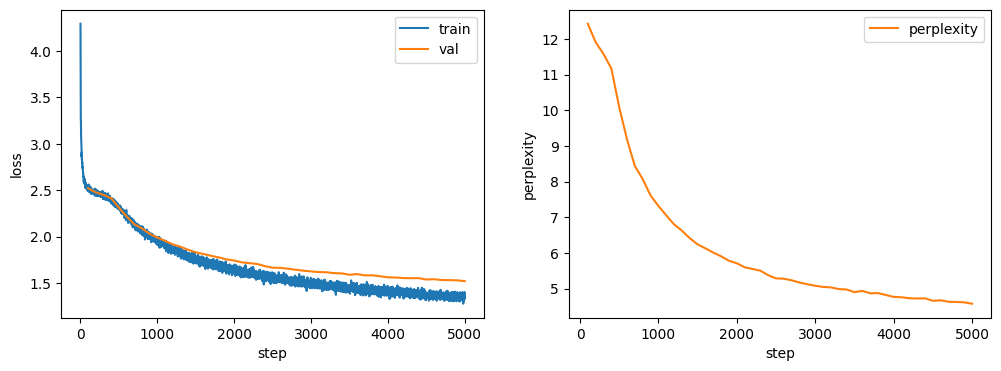

Final val loss: 1.5203
Final val perplexity: 4.58


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

metrics = pd.read_csv(f"{csv_logger.log_dir}/metrics.csv")
train = metrics[['step', 'train_loss']].dropna()
val = metrics[['step', 'val_loss']].dropna()
perplexity = metrics[['step', 'val_perplexity']].dropna()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(train['step'], train['train_loss'], label='train')
ax[0].plot(val['step'], val['val_loss'], label='val')
ax[0].set_xlabel('step')
ax[0].set_ylabel('loss')
ax[0].legend()
ax[1].plot(perplexity['step'], perplexity['val_perplexity'], label='perplexity', color='tab:orange')
ax[1].set_xlabel('step')
ax[1].set_ylabel('perplexity')
ax[1].legend()
plt.show()

if not val.empty:
    print(f"Final val loss: {val['val_loss'].iloc[-1]:.4f}")
if not perplexity.empty:
    print(f"Final val perplexity: {perplexity['val_perplexity'].iloc[-1]:.2f}")

Generate sample text. Test: run to produce a 500-token sample output.

In [11]:
model_to_use = model._orig_mod if hasattr(model, '_orig_mod') else model
model_to_use = model_to_use.to(device).eval()
context = torch.zeros((1, 1), dtype=torch.long, device=device)
with torch.no_grad():
    generated = model_to_use.generate(context, max_new_tokens=500)[0].tolist()
print(decode(generated))


ELBOW:
Good wives him land against, you for erread
I cried, to God's serve me exeter; yet to the moon.
Methought of you art did make it my life,
For your lip in this wolver's complixence
In this that forsul was my just ten my sword.

JULIET:
Nay, how something like the clouds of his mocks
And the possions of lebove the eny of it;
The gosses and more 'fair, shall it soing.
What should you so good attend for with be answer
In that give him but and fains my life,
So haard for wrong'd him respite,
I
